## Librerias

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Lambda
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


# VERIFICACION DATOS FALTANTES

In [3]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('../../data/processed/DATOS_PROCESADOS_temp_roc.csv')

In [4]:
df_pre_copy = df_datos_preprocesados.copy()

In [5]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT,13.0,8.0
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT,11.0,10.0
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT,9.0,9.0
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT,8.0,8.0
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT,9.0,8.0


valores nulos en temperatura y rocio

In [6]:
#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
282,2006-09-05 10:00:00.000,2006,9,5,10,31003KT,NaN,NaN
401,2006-09-11 09:00:00.000,2006,9,11,9,VRB02KT,NaN,NaN
1066,2006-10-13 07:00:00.000,2006,10,13,7,30002KT,NaN,NaN
1420,2006-12-28 13:00:00.000,2006,12,28,13,02005KT,NaN,NaN
1874,2007-03-23 00:00:00.000,2007,3,23,0,VRB02KT,NaN,NaN


In [7]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


In [8]:
df_pre_copy.tail()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt
FECHA_REPORTE,,,,,,
2026-04-09 14:27:00,16014G25KT,17.0,10.0,160.0,14.0,25.0
2026-04-09 15:00:00,15017KT,18.0,10.0,150.0,17.0,0.0
2026-04-09 16:00:00,18015KT,17.0,10.0,180.0,15.0,0.0
2026-04-09 17:00:00,15011KT,17.0,10.0,150.0,11.0,0.0
2026-04-09 18:00:00,17011KT,18.0,10.0,170.0,11.0,0.0


### Datos faltantes

In [9]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('h'),
                              end=df_pre_copy.index.max().ceil('h'),
                              freq='1h')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


#### Descomposicion de dirección e intensidad del viento

In [10]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('h')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:


radianes = df_pre_copy['direccion'] * (np.pi / 180)
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(radianes)
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(radianes)

In [11]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,u,v
FECHA_REPORTE,,,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0,-2.000000,-3.464102
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0,3.758770,-1.368081
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0,1.879385,-0.684040


Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [12]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE


# 2. Definir reglas de agregación para tus columnas
reglas = {
    'u': 'mean',          # Promedio de la componente zonal
    'v': 'mean'        # Promedio de la componente meridional
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1h').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['u'] = df_modelo['u'].interpolate(method='linear')
df_modelo['v'] = df_modelo['v'].interpolate(method='linear')

In [13]:
df_modelo.tail()

,u,v
FECHA_REPORTE,,
2026-04-09 14:00:00,-4.788282e+00,13.155697
2026-04-09 15:00:00,-8.500000e+00,14.722432
2026-04-09 16:00:00,-1.836970e-15,15.000000
2026-04-09 17:00:00,-5.500000e+00,9.526279
2026-04-09 18:00:00,-1.910130e+00,10.832885


In [14]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'h')

Cantidad de valores faltantes por columna:
u    0
v    0
dtype: int64

¿Es el índice estrictamente regular (1H)?: True


In [15]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('h')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


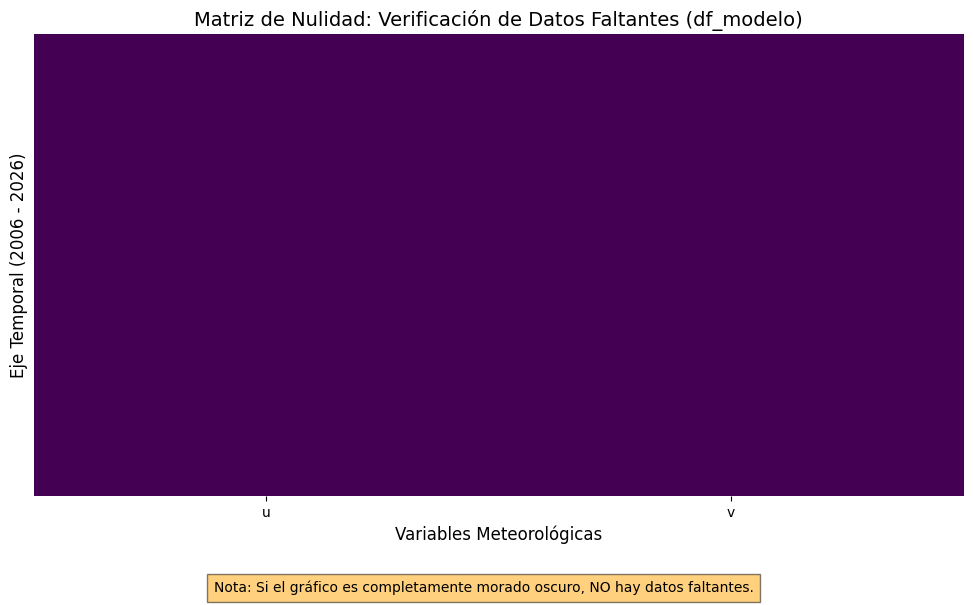

In [16]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [17]:
# Filtrar desde 2013
df_lstm = df_modelo.loc['2013-01-01':, ['u', 'v']].copy()

In [19]:
df_lstm['FECHA'] = df_lstm.index

In [20]:
df_lstm.head()

,u,v,FECHA
FECHA_REPORTE,,,
2013-01-01 00:00:00,-0.520945,-2.954423,2013-01-01 00:00:00
2013-01-01 01:00:00,-2.500000,-4.330127,2013-01-01 01:00:00
2013-01-01 02:00:00,-2.819078,-1.026060,2013-01-01 02:00:00
2013-01-01 03:00:00,-1.500000,-2.598076,2013-01-01 03:00:00
2013-01-01 04:00:00,-2.000000,-3.464102,2013-01-01 04:00:00


In [22]:
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = '../../data/processed/DATOS_ENTRENAMIENTO_u_v.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_lstm.to_csv(ruta_exportacion, index=False)

In [19]:
df_lstm.head()

,u,v
FECHA_REPORTE,,
2013-01-01 00:00:00,-0.520945,-2.954423
2013-01-01 01:00:00,-2.500000,-4.330127
2013-01-01 02:00:00,-2.819078,-1.026060
2013-01-01 03:00:00,-1.500000,-2.598076
2013-01-01 04:00:00,-2.000000,-3.464102


In [20]:
df_lstm.describe()

,u,v
count,116323.000000,116323.000000
mean,-0.868066,-0.268676
std,5.191485,5.135471
min,-94.541544,-889.281401
25%,-3.856726,-2.954423
50%,-1.349706,-1.532089
75%,1.732051,1.532089
max,781.154914,118.176930


# PRUEBA DE MODELOS

## LSTM

In [24]:
features_modelo = ['u', 'v']
targets = ['u','v']
# ========== 1. PARTICIÓN CRONOLÓGICA PRIMERO ==========
print("Realizando partición cronológica antes de escalar...")

train_df = df_lstm.loc[:'2024-12-31'].copy()
val_df = df_lstm.loc['2025-01-01':'2025-12-31'].copy()
test_df = df_lstm.loc['2026-01-01':].copy()

# ========== 2. NORMALIZACIÓN (EVITANDO LEAKAGE) ==========
print("Normalizando variables correctamente...")

# ========== 1. ENTRENAMIENTO DE ESCALADORES (Fit) ==========
# Se ajustan ÚNICAMENTE con los datos crudos de entrenamiento
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Ajustamos ambos (aunque sean iguales, mantenemos la lógica de X e y)
scaler_X.fit(train_df[features_modelo])
scaler_y.fit(train_df[targets])

# ========== 2. TRANSFORMACIÓN (Transform) ==========
# IMPORTANTE: Transformamos y asignamos a variables nuevas para evitar el re-escalamiento 
# accidental de las columnas del DataFrame original en la misma celda.

# Train
X_train_scaled = scaler_X.transform(train_df[features_modelo])
y_train_scaled = scaler_y.transform(train_df[targets])

# Validation
X_val_scaled   = scaler_X.transform(val_df[features_modelo])
y_val_scaled   = scaler_y.transform(val_df[targets])

# Test
X_test_scaled  = scaler_X.transform(test_df[features_modelo])
y_test_scaled  = scaler_y.transform(test_df[targets])

print(f"Media de scaler_y: {scaler_y.mean_}")
print(f"Escala de scaler_y: {scaler_y.scale_}")

Realizando partición cronológica antes de escalar...
Normalizando variables correctamente...
Media de scaler_y: [-0.90920821 -0.24399109]
Escala de scaler_y: [5.28395897 5.26741466]


Generación secuencias para LSTM

In [25]:
# ========== 1. ASIGNACIÓN DE TENSORES (POST-ESCALAMIENTO) ==========
# Ya no extraemos del DataFrame porque los objetos X_train_scaled, etc.
# ya son arrays de NumPy con los datos normalizados correctamente.

Xtrain_data = X_train_scaled
y_train     = y_train_scaled

Xval_data   = X_val_scaled
y_val       = y_val_scaled

Xtest_data  = X_test_scaled
y_test      = y_test_scaled

print("Tensores asignados exitosamente desde variables escaladas.")

Tensores asignados exitosamente desde variables escaladas.


In [26]:
# ========== 2. CONFIGURACIÓN DE GENERADORES ==========

# Parámetros metodológicos
n_back = 20           # Ventana de timesteps (rezagos)
batch_size_train = 300 
batch_size_test = 1    

# Generador de Entrenamiento: Aprende patrones con el escalamiento de 2013-2024
train_generator = TimeseriesGenerator(
    Xtrain_data, 
    y_train,
    length=n_back, 
    batch_size=batch_size_train
)

# Generador de Validación: Evalúa el desempeño en 2025 (escalado con parámetros de train)
val_generator = TimeseriesGenerator(
    Xval_data, 
    y_val, 
    length=n_back, 
    batch_size=batch_size_train # Usamos batch grande para acelerar validación
)

# Generador de Prueba: Evaluación final 2026 (Inferencia uno a uno)
test_generator = TimeseriesGenerator(
    Xtest_data, 
    y_test, 
    length=n_back, 
    batch_size=batch_size_test
)

# ========== 3. VERIFICACIÓN TÉCNICA DE TENSORES ==========
x_batch, y_batch = train_generator[0]
print("--- Diagnóstico de Estructura de Datos ---")
print(f"Input Shape (X): {x_batch.shape} -> (Batch, Ventana, Features)")
print(f"Target Shape (y): {y_batch.shape} -> (Batch, Targets)")

# Verificación de valores (opcional para control de calidad)
print(f"Media aproximada en Train (X): {x_batch.mean():.4f} (debería ser cercana a 0)")

--- Diagnóstico de Estructura de Datos ---
Input Shape (X): (300, 20, 2) -> (Batch, Ventana, Features)
Target Shape (y): (300, 2) -> (Batch, Targets)
Media aproximada en Train (X): -0.1159 (debería ser cercana a 0)


Entrenamiento modelo LSTM

In [44]:
# Número de variables entradas (u,v, temperatura, rocio)
n_features = 2
n_outputs = 2  # Solo queremos predecir u,v
neuronas_ocultas = 300

# 1. Diseño de la Arquitectura del Modelo (Estrictamente 3 capas)
model = Sequential()

# Capa 1: Entrada
model.add(Input(shape=(n_back, n_features)))

# Capa 2: Única Capa Oculta LSTM
model.add(LSTM(
    units=neuronas_ocultas,
    activation='tanh',               # Estándar del estudio
    recurrent_activation='sigmoid'   # Estándar del estudio para las gates
))

# Capa 3: Capa de salida
model.add(Dense(
    units=n_outputs, 
    activation='linear'              # Estándar del estudio para regresión
))

# 2. Compilación
# El estudio empleó Adam con sus valores por defecto en TensorFlow y MSE
model.compile(optimizer=Adam(), loss='mse')
print("Estructura de la Red Neuronal del Proyecto (Alves et al., 2024):")
model.summary()

# Callbacks para early stopping (Paciencia de 10 épocas según el estudio)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

# 3. Entrenamiento
num_epochs = 50


Estructura de la Red Neuronal del Proyecto (Alves et al., 2024):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 300)            │       363,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,202 (1.39 MB)

 Trainable params: 364,202 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - loss: 0.6378 - val_loss: 0.2598
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - loss: 0.6076 - val_loss: 0.2479
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - loss: 0.6036 - val_loss: 0.2469
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - loss: 0.6007 - val_loss: 0.2457
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 101ms/step - loss: 0.5988 - val_loss: 0.2442
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - loss: 0.5978 - val_loss: 0.2450
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - loss: 0.5968 - val_loss: 0.2433
Epoch 8/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - loss: 0.5951 - val_loss: 0.2427
Epoch 9/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - loss: 0.5941 - val_loss: 0.2503
Epoch 10/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - loss: 0.5933 - val_loss: 0.2603
Epoch 11/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - loss: 0.5928 - val_loss: 0.2438
Epoch 12/50
351/351 ━━━━━━━

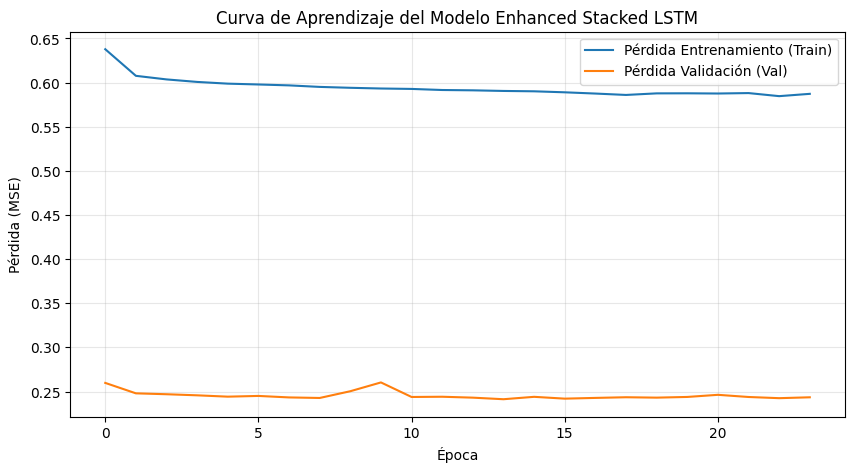

In [29]:

# Al llamar a model.fit, asegúrate de incluir el batch_size de 512 que usó el estudio:
history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=num_epochs, 
    batch_size=512,          # ¡Dato crítico del estudio!
    callbacks=callbacks, 
    verbose=1 
)


# 4. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val)')
plt.title('Curva de Aprendizaje del Modelo Enhanced Stacked LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prueba de oncepto a 6h

In [30]:
def predict_autoregressive_uv(modelo, initial_window, horizon):
    """
    Realiza el pronóstico iterativo usando solo componentes u y v.
    - initial_window: Array con forma (1, n_back, 2)
    - horizon: Pasos de tiempo a predecir (ej. 6)
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for _ in range(horizon):
        # 1. Inferencia: El modelo recibe (1, 48, 2) y devuelve (1, 2) -> [u, v]
        next_uv = modelo.predict(current_window, verbose=0) 
        predictions.append(next_uv[0])
        
        # 2. Reshape para añadir un nuevo timestep: (1, 1, 2)
        next_step_3d = next_uv.reshape(1, 1, 2)
        
        # 3. Actualizar ventana: Deslizar (quitar el primero) y añadir la predicción
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_3d],
            axis=1
        )
    
    return np.array(predictions) # Forma (6, 2)

In [31]:
# Definir horizonte de predicción
horizonte_pred = 6

# 1. Extraer las últimas 48 horas del set de validación
# Xval_data ya está escalado y tiene forma (N, 2)
ultima_ventana_val = Xval_data[-n_back:]  # Forma: (48, 2)

# 2. Expandir a 3D para que Keras lo procese (Batch, Time, Features)
# Forma resultante: (1, 48, 2)
ultima_ventana_val_3d = np.expand_dims(ultima_ventana_val, axis=0)

In [32]:
# Generar el pronóstico en escala normalizada (Z-score)
print("Generando pronóstico autoregresivo...")

forecast_escalado = predict_autoregressive_uv(
    model, 
    ultima_ventana_val_3d, 
    horizon=horizonte_pred
)

print(f"Variable 'forecast_escalado' generada. Forma: {forecast_escalado.shape}")
# Debería mostrar (6, 2)

Generando pronóstico autoregresivo...
Variable 'forecast_escalado' generada. Forma: (6, 2)


In [33]:
horizon = 6
forecast_escalado

array([[-0.44401368, -0.38267624],
       [-0.34373072, -0.34334576],
       [-0.31257635, -0.39682323],
       [-0.29783067, -0.43320388],
       [-0.27194366, -0.45233405],
       [-0.2410134 , -0.45309138]], dtype=float32)

In [34]:
# 1. Obtener predicciones y valores reales en escala original
forecast_real = scaler_y.inverse_transform(forecast_escalado)
real_real     = scaler_y.inverse_transform(y_test[:horizon])
historia_real = scaler_y.inverse_transform(y_val[-n_back:])

def uv_a_meteorologia(matriz):
    u, v = matriz[:, 0], matriz[:, 1]
    # Intensidad (kt)
    intensidad = np.sqrt(u**2 + v**2)
    # Dirección (°) - Usando la convención original u = -I*sin, v = -I*cos
    direccion = (np.degrees(np.arctan2(-u, -v))) % 360
    return intensidad, direccion

int_p, dir_p = uv_a_meteorologia(forecast_real)
int_r, dir_r = uv_a_meteorologia(real_real)
int_h, dir_h = uv_a_meteorologia(historia_real)

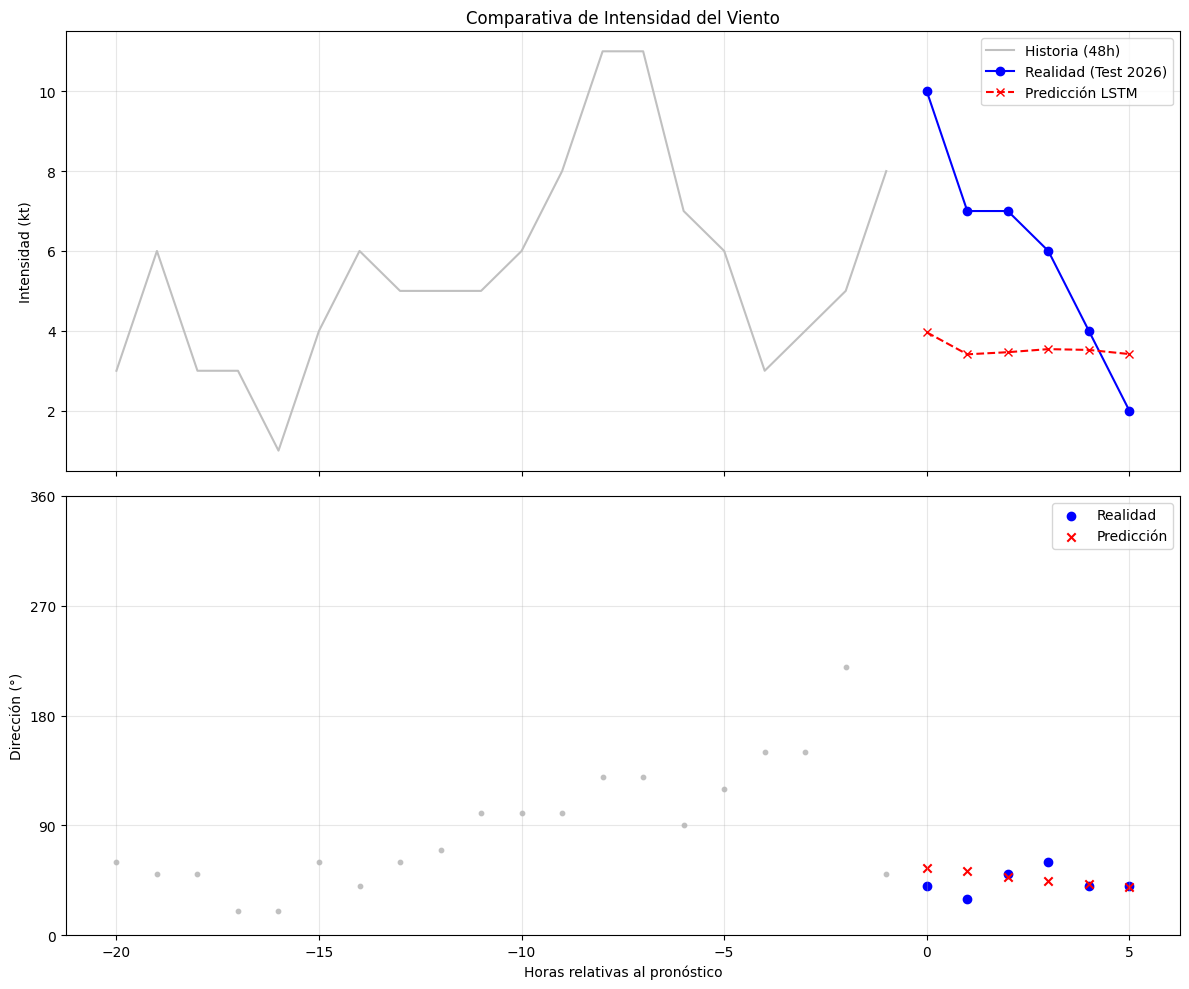

In [35]:
# --- A. Des-normalización ---
# Recuperamos los nudos (kt) reales
forecast_real = scaler_y.inverse_transform(forecast_escalado)
real_real     = scaler_y.inverse_transform(y_test[:horizonte_pred])
historia_real = scaler_y.inverse_transform(y_val[-n_back:])

# --- B. Conversión a Magnitudes Físicas ---
# Usamos la función uv_a_meteorologia definida anteriormente
int_p, dir_p = uv_a_meteorologia(forecast_real)
int_r, dir_r = uv_a_meteorologia(real_real)
int_h, dir_h = uv_a_meteorologia(historia_real)

# --- C. Generación de Gráfica ---
import matplotlib.pyplot as plt

tiempo_h = np.arange(-n_back, 0)
tiempo_p = np.arange(0, horizonte_pred)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Subplot 1: Intensidad (Velocidad)
ax1.plot(tiempo_h, int_h, color='silver', label='Historia (48h)')
ax1.plot(tiempo_p, int_r, 'b-o', label='Realidad (Test 2026)')
ax1.plot(tiempo_p, int_p, 'r--x', label='Predicción LSTM')
ax1.set_ylabel('Intensidad (kt)')
ax1.set_title('Comparativa de Intensidad del Viento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Dirección
ax2.scatter(tiempo_h, dir_h, color='silver', s=10)
ax2.scatter(tiempo_p, dir_r, color='blue', label='Realidad')
ax2.scatter(tiempo_p, dir_p, color='red', marker='x', label='Predicción')
ax2.set_ylabel('Dirección (°)')
ax2.set_xlabel('Horas relativas al pronóstico')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Walk-forward con LSTM

In [36]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def evaluar_modelo_lstm_uv(modelo, data_X_escalada, data_y_escalada, scaler_y,
                           seq_length=48, horizon=6, dataset_name="Test", umbral_calma=2.0):
    
    print(f"Iniciando evaluación Walk-Forward (Solo u,v) para el set de {dataset_name}...")
    
    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} 
                    for h in range(1, horizon + 1)}
    
    # El bucle avanza saltando el horizonte para evaluar bloques de 6 horas
    for t in range(seq_length, len(data_X_escalada) - horizon, horizon):
        
        # 1. Preparar la ventana de entrada (t-48 a t) -> Forma (1, 48, 2)
        ventana_actual_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)
        
        # 2. Generar el forecast autoregresivo (SOLO u, v)
        # Llamamos a la función simplificada que no requiere exog_future
        forecast_escalado = predict_autoregressive_uv(
            modelo,
            ventana_actual_3d,
            horizon
        )
        
        # 3. Desescalar predicciones y valores reales (Z-score -> Unidades Reales)
        forecast_real = scaler_y.inverse_transform(forecast_escalado)
        real_real     = scaler_y.inverse_transform(data_y_escalada[t : t + horizon])
        
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # --- COMPONENTES REALES ---
            u_r, v_r = real_real[h_idx]
            int_r = np.sqrt(u_r**2 + v_r**2)
            dir_r = np.degrees(np.arctan2(-u_r, -v_r)) % 360
            
            # --- COMPONENTES PREDICHAS ---
            u_p, v_p = forecast_real[h_idx]
            int_p = np.sqrt(u_p**2 + v_p**2)
            dir_p = np.degrees(np.arctan2(-u_p, -v_p)) % 360
            
            # Almacenar Intensidad
            resultados_h[paso]['int_real'].append(int_r)
            resultados_h[paso]['int_pred'].append(int_p)
            
            # Almacenar Dirección (Aplicando umbral de calma)
            if int_r >= umbral_calma:
                resultados_h[paso]['dir_real'].append(dir_r)
                resultados_h[paso]['dir_pred'].append(dir_p)

    # 4. Consolidación de Reporte
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)], 
                           columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])
    
    for h in range(1, horizon + 1):
        i_r, i_p = np.array(resultados_h[h]['int_real']), np.array(resultados_h[h]['int_pred'])
        d_r, d_p = np.array(resultados_h[h]['dir_real']), np.array(resultados_h[h]['dir_pred'])
        
        # MAE Intensidad
        mae_int = mean_absolute_error(i_r, i_p)
        
        # MAE Dirección (Métrica Circular)
        diff = np.abs(d_r - d_p)
        mae_dir = np.mean(np.minimum(diff, 360 - diff))
        
        reporte.loc[f"Hora {h}"] = [mae_int, mae_dir]
        
    print(f"\n--- REPORTE FINAL: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(3))
    return reporte

In [37]:
# Evaluar en Validación (2025)
reporte_val_lstm = evaluar_modelo_lstm_uv(
    model, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Validación (2025)"
)

# Evaluar en Test (2026 - Datos nunca vistos)
reporte_test_lstm = evaluar_modelo_lstm_uv(
    model, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Test (2026)"
)

Iniciando evaluación Walk-Forward (Solo u,v) para el set de Validación (2025)...

--- REPORTE FINAL: VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                1.657                  33.048
Hora 2                2.039                  41.183
Hora 3                2.241                  44.183
Hora 4                2.290                  44.783
Hora 5                2.307                  47.837
Hora 6                2.350                  47.161
Iniciando evaluación Walk-Forward (Solo u,v) para el set de Test (2026)...

--- REPORTE FINAL: TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                1.651                  34.933
Hora 2                1.700                  43.928
Hora 3                1.975                  46.119
Hora 4                2.222                  50.456
Hora 5                2.305                  50.337
Hora 6                2.483                  47.569


In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def evaluar_modelo_operativo_369(modelo, data_X_escalada, data_y_escalada, scaler_y,
                                 seq_length=20, horizon=9, step_size=6, 
                                 dataset_name="Test", umbral_calma=2.0):
    
    print(f"Iniciando evaluación OPERATIVA (Saltos de {step_size}h) para {dataset_name}...")
    
    # 1. Definir las franjas de alcance que queremos observar
    franjas_objetivo = [3, 6, 9]
    
    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} 
                    for h in franjas_objetivo}
    
    # 2. Bucle Operativo: Avanza en bloques (step_size=6) en lugar de hora por hora
    # Esto simula la emisión de un nuevo TAF cada 6 horas reales.
    for t in range(seq_length, len(data_X_escalada) - horizon, step_size):
        
        # Preparar la memoria del modelo (últimas 20 horas)
        ventana_actual_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)
        
        # Generar el pronóstico a 9 horas a futuro
        forecast_escalado = predict_autoregressive_uv(modelo, ventana_actual_3d, horizon)
        
        # Desescalar predicciones y reales a unidades físicas (Nudos)
        forecast_real = scaler_y.inverse_transform(forecast_escalado)
        real_real     = scaler_y.inverse_transform(data_y_escalada[t : t + horizon])
        
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # 3. Guardar solo las fotos de las horas 3, 6 y 9
            if paso in franjas_objetivo:
                # --- REALES ---
                u_r, v_r = real_real[h_idx]
                int_r_kt = np.sqrt(u_r**2 + v_r**2)
                dir_r = np.degrees(np.arctan2(-u_r, -v_r)) % 360
                
                # --- PREDICCIONES ---
                u_p, v_p = forecast_real[h_idx]
                int_p_kt = np.sqrt(u_p**2 + v_p**2)
                dir_p = np.degrees(np.arctan2(-u_p, -v_p)) % 360
                
                # Almacenar datos
                resultados_h[paso]['int_real'].append(int_r_kt)
                resultados_h[paso]['int_pred'].append(int_p_kt)
                
                # Umbral de calma: FMH-1 dicta que vientos < 2 kt tienen dirección variable/errática
                if int_r_kt >= umbral_calma:
                    resultados_h[paso]['dir_real'].append(dir_r)
                    resultados_h[paso]['dir_pred'].append(dir_p)

    # 4. Cálculo de MSE (Intensidad) y RMSE (Dirección)
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in franjas_objetivo], 
                           columns=['MSE_Intensidad (kt²)', 'RMSE_Direccion (grados)'])
    
    for h in franjas_objetivo:
        i_r = np.array(resultados_h[h]['int_real'])
        i_p = np.array(resultados_h[h]['int_pred'])
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])
        
        # MSE de Intensidad
        mse_int = mean_squared_error(i_r, i_p)
        
        # RMSE de Dirección (Métrica Circular para evitar el problema de los 360/0 grados)
        diff = np.abs(d_r - d_p)
        error_circular = np.minimum(diff, 360 - diff)
        mse_dir_circular = np.mean(error_circular**2) 
        rmse_dir = np.sqrt(mse_dir_circular) # Raíz para devolver a grados interpretables
        
        reporte.loc[f"Hora {h}"] = [mse_int, rmse_dir]
        
    print(f"\n--- REPORTE FINAL: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    return reporte

In [47]:
# Evaluar en Validación (2025)
reporte_val_lstm = evaluar_modelo_lstm_uv(
    model, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Validación (2025)"
)

Iniciando evaluación Walk-Forward (Solo u,v) para el set de Validación (2025)...

--- REPORTE FINAL: VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                3.966                  81.358
Hora 2                3.990                  78.364
Hora 3                3.949                  75.659
Hora 4                3.864                  75.973
Hora 5                3.874                  75.943
Hora 6                4.002                  74.408


In [40]:

# Evaluar en Test (2026 - Datos nunca vistos)
reporte_test_lstm = evaluar_modelo_lstm_uv(
    model, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Test (2026)"
)

Iniciando evaluación Walk-Forward (Solo u,v) para el set de Test (2026)...

--- REPORTE FINAL: TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                1.651                  34.933
Hora 2                1.700                  43.928
Hora 3                1.975                  46.119
Hora 4                2.222                  50.456
Hora 5                2.305                  50.337
Hora 6                2.483                  47.569


Prueba modelo 2

In [58]:

# ==========================================
# 1. FUNCIONES DE APOYO (UTILITIES)
# ==========================================

def unit_norm_vectorized(u, v):
    """Convierte componentes u, v en vectores unitarios."""
    mag = np.sqrt(u**2 + v**2)
    mag = np.where(mag == 0, 1e-8, mag)  # Evitar división por cero
    return u / mag, v / mag

def angular_error(y_true, y_pred):
    # Forzar casting a float32 para evitar conflictos de precisión
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Asegurar normalización
    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)
    
    # Producto punto (Similitud Coseno)
    cosine_sim = tf.reduce_sum(y_true * y_pred, axis=-1)
    cosine_sim = tf.clip_by_value(cosine_sim, -1.0, 1.0)
    
    # De radianes a grados
    angle_rad = tf.math.acos(cosine_sim)
    return angle_rad * (180.0 / np.pi)

# ==========================================
# 2. PRE-PROCESAMIENTO Y PARTICIÓN
# ==========================================

features_modelo = ['u', 'v']
targets = ['u', 'v']

# Partición Cronológica
train_df = df_lstm.loc[:'2024-12-31'].copy()
val_df   = df_lstm.loc['2025-01-01':'2025-12-31'].copy()
test_df  = df_lstm.loc['2026-01-01':].copy()

# A. Normalización de Entradas (X) -> StandardScaler
scaler_X = StandardScaler()
scaler_X.fit(train_df[features_modelo])

# Justo antes de asignar a Xtrain_data, y_train, etc.
Xtrain_data = X_train_scaled.astype('float32')
y_train     = y_train.astype('float32')

Xval_data   = X_val_scaled.astype('float32')
y_val       = y_val.astype('float32')

Xtest_data  = X_test_scaled.astype('float32')
y_test      = y_test.astype('float32')

# B. Normalización de Salidas (y) -> Vectores Unitarios
# IMPORTANTE: Aquí no usamos StandardScaler para y
u_train_u, v_train_u = unit_norm_vectorized(train_df['u'].values, train_df['v'].values)
y_train = np.stack([u_train_u, v_train_u], axis=1)

u_val_u, v_val_u = unit_norm_vectorized(val_df['u'].values, val_df['v'].values)
y_val = np.stack([u_val_u, v_val_u], axis=1)

u_test_u, v_test_u = unit_norm_vectorized(test_df['u'].values, test_df['v'].values)
y_test = np.stack([u_test_u, v_test_u], axis=1)

# ==========================================
# 3. GENERADORES DE TIEMPO
# ==========================================

n_back = 20
batch_size_train = 300

train_generator = TimeseriesGenerator(Xtrain_data, y_train, length=n_back, batch_size=batch_size_train)
val_generator   = TimeseriesGenerator(Xval_data, y_val, length=n_back, batch_size=batch_size_train)
test_generator  = TimeseriesGenerator(Xtest_data, y_test, length=n_back, batch_size=1)


In [59]:
# ==========================================
# 4. ARQUITECTURA DEL MODELO (DIRECCIÓN)
# ==========================================

model_dir = Sequential([
    Input(shape=(n_back, len(features_modelo))),
    
    # Capa LSTM Única
    LSTM(units=300, activation='tanh', recurrent_activation='sigmoid'),
    
    # Capa de salida con 2 neuronas (u, v)
    Dense(units=2, activation='linear'),
    
    # CAPA CLAVE: Normalización L2 para forzar salida al círculo unitario
    Lambda(lambda x: tf.math.l2_normalize(x, axis=1), name='L2_Normalization')
])

model_dir.compile(
    optimizer=Adam(),
    loss='cosine_similarity', # El loss tenderá a -1.0
    metrics=[angular_error]    # Veremos el error en grados reales
)

# Entrenamiento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_dir_model.keras', monitor='val_loss', save_best_only=True)
]


Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - angular_error: 32.6435 - loss: -0.7397 - val_angular_error: 31.2997 - val_loss: -0.7561
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - angular_error: 32.5179 - loss: -0.7410 - val_angular_error: 30.9733 - val_loss: -0.7575
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - angular_error: 32.4589 - loss: -0.7419 - val_angular_error: 31.1602 - val_loss: -0.7571
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - angular_error: 32.3943 - loss: -0.7422 - val_angular_error: 31.0786 - val_loss: -0.7591
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - angular_error: 32.3998 - loss: -0.7426 - val_angular_error: 31.1026 - val_loss: -0.7571
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - angular_error: 32.4007 - loss: -0.7425 - val_angular_error: 31.3505 - val_loss: -0.7562
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - angular_error: 32.3831 - loss: -0.7427 - val_angular_error: 31.1181 - val_loss: 

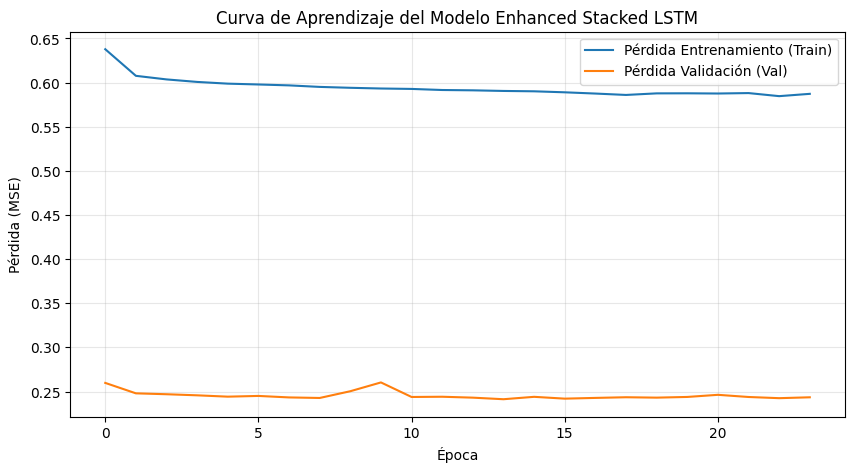

In [61]:

# Al llamar a model.fit, asegúrate de incluir el batch_size de 512 que usó el estudio:
history2 = model_dir.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=num_epochs, 
    batch_size=512,          # ¡Dato crítico del estudio!
    callbacks=callbacks, 
    verbose=1 
)


# 4. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val)')
plt.title('Curva de Aprendizaje del Modelo Enhanced Stacked LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [62]:

# ==========================================
# 5. POST-PROCESAMIENTO (INFERENCIA)
# ==========================================

# Predecir sobre el set de prueba
y_pred_unit = model_dir.predict(test_generator)

# Convertir vectores unitarios a grados (0-360)
def vector_to_degrees(u, v):
    radians = np.arctan2(v, u)
    degrees = np.degrees(radians)
    return np.mod(degrees, 360)

pred_degrees = vector_to_degrees(y_pred_unit[:, 0], y_pred_unit[:, 1])

print(f"Predicciones de dirección (primeros 5): {pred_degrees[:5]}")

2351/2351 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Predicciones de dirección (primeros 5): [352.27847 342.48032 358.64175 351.86533 359.3016 ]


In [63]:
def predict_autoregressive_dir(modelo, initial_window, horizon, scaler_X):
    """
    Pronóstico iterativo para DIRECCIÓN.
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for _ in range(horizon):
        # 1. Inferencia: Devuelve vector unitario (1, 2) -> [u_unit, v_unit]
        next_uv_unit = modelo.predict(current_window, verbose=0) 
        predictions.append(next_uv_unit[0])
        
        # 2. PREPARACIÓN PARA RETROALIMENTACIÓN:
        # El modelo espera entradas escaladas por scaler_X. 
        # Como no tenemos la intensidad futura, usamos el vector unitario 
        # y lo pasamos por el scaler_X para mantener la escala de la ventana.
        next_step_scaled = scaler_X.transform(next_uv_unit) 
        next_step_3d = next_step_scaled.reshape(1, 1, 2)
        
        # 3. Actualizar ventana
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_3d],
            axis=1
        )
    
    return np.array(predictions).astype('float32')

In [64]:
# --- A. Generar Pronóstico ---
forecast_dir_unit = predict_autoregressive_dir(
    model_dir, 
    ultima_ventana_val_3d, 
    horizon=horizonte_pred,
    scaler_X=scaler_X
)

# --- B. Conversión a Grados (Dirección) ---
def unit_uv_to_degrees(matriz_unit):
    u = matriz_unit[:, 0]
    v = matriz_unit[:, 1]
    # Usamos arctan2 para obtener el ángulo real
    # Si usas la convención meteorológica: (270 - deg) % 360
    # Si usas convención matemática estándar:
    return np.mod(np.degrees(np.arctan2(v, u)), 360)

dir_p = unit_uv_to_degrees(forecast_dir_unit)

# --- C. Recuperar Valores Reales para Comparar ---
# Para la realidad (y_test), recuerda que los guardamos como unitarios
dir_r = unit_uv_to_degrees(y_test[:horizonte_pred])
dir_h = unit_uv_to_degrees(y_val[-n_back:])

/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MA

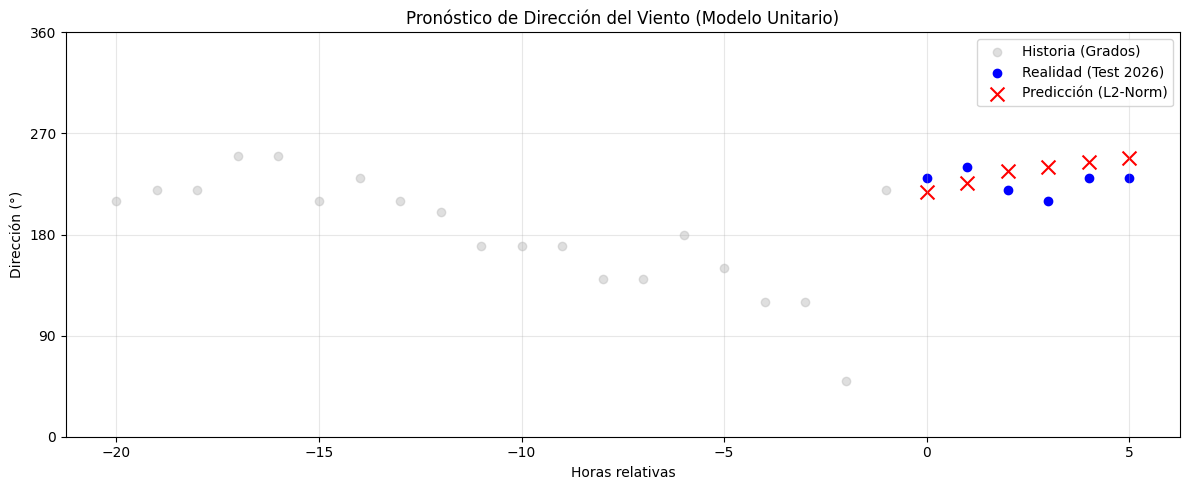

In [65]:
import matplotlib.pyplot as plt

tiempo_h = np.arange(-n_back, 0)
tiempo_p = np.arange(0, horizonte_pred)

# Graficamos solo Dirección por ahora (Subplot 2 de tu código original)
plt.figure(figsize=(12, 5))

plt.scatter(tiempo_h, dir_h, color='silver', alpha=0.5, label='Historia (Grados)')
plt.scatter(tiempo_p, dir_r, color='blue', label='Realidad (Test 2026)')
plt.scatter(tiempo_p, dir_p, color='red', marker='x', s=100, label='Predicción (L2-Norm)')

plt.title('Pronóstico de Dirección del Viento (Modelo Unitario)')
plt.ylabel('Dirección (°)')
plt.xlabel('Horas relativas')
plt.yticks([0, 90, 180, 270, 360])
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
def evaluar_modelo_direccion_wf(modelo, data_X_escalada, data_y_unit, scaler_X, 
                                 seq_length=48, horizon=6, dataset_name="Test"):
    """
    Evaluación Walk-Forward específica para el modelo de DIRECCIÓN con L2-Norm.
    """
    print(f"Iniciando evaluación Walk-Forward para DIRECCIÓN ({dataset_name})...")
    
    # Solo almacenamos dirección ya que este modelo es especializado
    resultados_h = {h: {'dir_real': [], 'dir_pred': []} for h in range(1, horizon + 1)}
    
    # Bucle Walk-Forward
    for t in range(seq_length, len(data_X_escalada) - horizon, horizon):
        
        # 1. Ventana de entrada (t-seq_length a t)
        ventana_actual_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)
        
        # 2. Pronóstico Autoregresivo (Usa la función que definimos antes)
        # Importante: Enviamos scaler_X para que la retroalimentación sea correcta
        forecast_unit = predict_autoregressive_dir(
            modelo, 
            ventana_actual_3d, 
            horizon, 
            scaler_X
        )
        
        # 3. Valores Reales (Ya son unitarios en tu variable y_val/y_test)
        real_unit = data_y_unit[t : t + horizon]
        
        # 4. Conversión a Grados y Almacenamiento
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # Dirección Real (desde vectores unitarios reales)
            u_r, v_r = real_unit[h_idx]
            dir_r = (np.degrees(np.arctan2(-u_r, -v_r))) % 360
            
            # Dirección Predicha (desde vectores unitarios predichos)
            u_p, v_p = forecast_unit[h_idx]
            dir_p = (np.degrees(np.arctan2(-u_p, -v_p))) % 360
            
            resultados_h[paso]['dir_real'].append(dir_r)
            resultados_h[paso]['dir_pred'].append(dir_p)

    # 5. Consolidación de Reporte (Métrica Circular)
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)], 
                           columns=['MAE_Direccion (grados)'])
    
    for h in range(1, horizon + 1):
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])
        
        # Cálculo del error circular (la ruta más corta en el círculo)
        diff = np.abs(d_r - d_p)
        mae_dir = np.mean(np.minimum(diff, 360 - diff))
        
        reporte.loc[f"Hora {h}"] = [mae_dir]
        
    print(f"\n--- REPORTE DE DIRECCIÓN: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(3))
    return reporte

In [67]:
# --- EJECUCIÓN ---
# Nota: y_val aquí son los vectores unitarios float32 que creamos antes
reporte_dir_val = evaluar_modelo_direccion_wf(
    model_dir, 
    Xval_data, 
    y_val, 
    scaler_X,
    seq_length=n_back, 
    horizon=horizonte_pred, 
    dataset_name="Validación (2025)"
)

Iniciando evaluación Walk-Forward para DIRECCIÓN (Validación (2025))...


/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MA


--- REPORTE DE DIRECCIÓN: VALIDACIÓN (2025) ---
        MAE_Direccion (grados)
Hora 1                  31.185
Hora 2                  42.695
Hora 3                  53.124
Hora 4                  55.196
Hora 5                  54.301
Hora 6                  53.173


/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/omarleonardoalbarracinmonsalve/Documents/2. ESTUDIO/MAESTRIA INTELIGENCIA ANALITICA DE DATOS/Prediccion-Cizalladura-SKBQ/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Solo direccion

In [68]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('../../data/processed/DATOS_PROCESADOS_temp_roc.csv')
df_pre_copy = df_datos_preprocesados.copy()

#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


In [69]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt
FECHA_REPORTE,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0


In [71]:
# 1. Convertir los grados a radianes
# La fórmula es: radianes = grados * (pi / 180)
df_pre_copy['direccion_rad'] = np.radians(df_pre_copy['direccion'])

# 2. Crear el componente Coseno (Eje X del círculo unitario)
df_pre_copy['dir_cos'] = np.cos(df_pre_copy['direccion_rad'])

# 3. Crear el componente Seno (Eje Y del círculo unitario)
df_pre_copy['dir_sin'] = np.sin(df_pre_copy['direccion_rad'])

# Opcional: Eliminar la columna de radianes intermedia
df_pre_copy.drop(columns=['direccion_rad'], inplace=True)

print(df_pre_copy[['direccion', 'dir_cos', 'dir_sin']].head())

df_lstm = df_pre_copy.copy()

                     direccion   dir_cos   dir_sin
FECHA_REPORTE                                     
2006-07-20 00:00:00       30.0  0.866025  0.500000
2006-07-20 01:00:00      290.0  0.342020 -0.939693
2006-07-20 05:00:00      290.0  0.342020 -0.939693
2006-07-20 06:00:00      290.0  0.342020 -0.939693
2006-07-20 07:00:00      290.0  0.342020 -0.939693


In [73]:
# Definimos las nuevas columnas
features_modelo = ['dir_cos', 'dir_sin']
targets = ['dir_cos', 'dir_sin']

# ========== 1. PARTICIÓN CRONOLÓGICA ==========
# Mantenemos tu estructura original para evitar data leakage
train_df = df_lstm.loc[:'2024-12-31'].copy()
val_df   = df_lstm.loc['2025-01-01':'2025-12-31'].copy()
test_df  = df_lstm.loc['2026-01-01':].copy()

# ========== 2. ASIGNACIÓN DIRECTA (SIN ESCALAR) ==========
# Convertimos directamente a float32 para evitar el error de dtypes en TensorFlow
Xtrain_data = train_df[features_modelo].values.astype('float32')
y_train     = train_df[targets].values.astype('float32')

Xval_data   = val_df[features_modelo].values.astype('float32')
y_val       = val_df[targets].values.astype('float32')

Xtest_data  = test_df[features_modelo].values.astype('float32')
y_test      = test_df[targets].values.astype('float32')

print("Partición completada. Los datos ya están en el rango [-1, 1].")

Partición completada. Los datos ya están en el rango [-1, 1].


In [74]:
# Parámetros
n_back = 48 # Sugiero aumentar a 48 si tienes datos horarios para captar el ciclo diario
batch_size_train = 300 

# Generador de Entrenamiento
train_generator = TimeseriesGenerator(
    Xtrain_data, 
    y_train,
    length=n_back, 
    batch_size=batch_size_train
)

# Generador de Validación
val_generator = TimeseriesGenerator(
    Xval_data, 
    y_val, 
    length=n_back, 
    batch_size=batch_size_train
)

# Generador de Prueba (Inferencia uno a uno)
test_generator = TimeseriesGenerator(
    Xtest_data, 
    y_test, 
    length=n_back, 
    batch_size=1
)

In [75]:
# Conservamos tus variables
n_features = 2  # dir_cos, dir_sin
n_outputs = 2 
neuronas_ocultas = 300

model = Sequential()

# Capa 1: Entrada (Igual)
model.add(Input(shape=(n_back, n_features)))

# Capa 2: Única Capa Oculta LSTM (Igual)
model.add(LSTM(
    units=neuronas_ocultas,
    activation='tanh',
    recurrent_activation='sigmoid'
))

# Capa 3: Capa de salida (Ajuste leve)
model.add(Dense(units=n_outputs, activation='linear'))

# EXCEPCIÓN NECESARIA: Capa de restricción geométrica
# No cuenta como capa de "aprendizaje", es una restricción física
model.add(Lambda(lambda x: tf.math.l2_normalize(x, axis=1)))

# 2. Compilación (Ajuste de Loss para dirección)
model.compile(optimizer=Adam(), loss='cosine_similarity')

print("Estructura ajustada para Dirección Pura (Sin/Cos):")
model.summary()

Estructura ajustada para Dirección Pura (Sin/Cos):


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 300)            │       363,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           602 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,202 (1.39 MB)

 Trainable params: 364,202 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# 1. Definir Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('best_model_dir_sin_cos.keras', monitor='val_loss', save_best_only=True)
]

# 2. Ejecutar Entrenamiento
print("Iniciando entrenamiento del modelo de Dirección Pura...")
history4 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Iniciando entrenamiento del modelo de Dirección Pura...
Epoch 1/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 91s 173ms/step - loss: -0.7145 - val_loss: -0.7695
Epoch 2/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 85s 162ms/step - loss: -0.7427 - val_loss: -0.7780
Epoch 3/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 83s 160ms/step - loss: -0.7442 - val_loss: -0.7744
Epoch 4/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 84s 161ms/step - loss: -0.7443 - val_loss: -0.7769
Epoch 5/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 87s 167ms/step - loss: -0.7447 - val_loss: -0.7772
Epoch 6/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 131s 251ms/step - loss: -0.7451 - val_loss: -0.7776
Epoch 7/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 121s 231ms/step - loss: -0.7453 - val_loss: -0.7787
Epoch 8/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 109s 209ms/step - loss: -0.7457 - val_loss: -0.7740
Epoch 9/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 110s 210ms/step - loss: -0.7458 - val_loss: -0.7774
Epoch 10/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 99s 189ms/step - loss: -0.7461 - val_loss: -0.7779
Epoch 11/50
521/521 ━━━━━━━━━

In [77]:
def predict_autoregressive_sin_cos(modelo, initial_window, horizon):
    """
    Realiza pronóstico iterativo para componentes sin/cos.
    initial_window: (1, n_back, 2) -> [[cos, sin], ...]
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for _ in range(horizon):
        # 1. Predicción: devuelve [cos, sin] normalizados L2
        next_step = modelo.predict(current_window, verbose=0) 
        predictions.append(next_step[0])
        
        # 2. Actualizar ventana (Deslizar y añadir)
        next_step_3d = np.expand_dims(next_step, axis=1) # (1, 1, 2)
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_3d], 
            axis=1
        )
        
    return np.array(predictions) # Forma (horizon, 2)

def evaluar_direccion_sin_cos_wf(modelo, data_X, data_y, seq_length=48, horizon=6):
    """
    Evaluación Walk-Forward para el modelo de dirección pura.
    data_y: contiene las columnas [dir_cos, dir_sin] reales.
    """
    print("Iniciando Walk-Forward Validation...")
    
    # Diccionario para almacenar errores por horizonte
    resultados_h = {h: {'error_angular': []} for h in range(1, horizon + 1)}
    
    # Bucle Walk-Forward (saltando por el horizonte)
    for t in range(seq_length, len(data_X) - horizon, horizon):
        
        # 1. Preparar ventana inicial
        ventana_3d = np.expand_dims(data_X[t - seq_length : t], axis=0)
        
        # 2. Obtener predicción autoregresiva (sin/cos)
        preds_sin_cos = predict_autoregressive_sin_cos(modelo, ventana_3d, horizon)
        
        # 3. Valores reales (sin/cos)
        reales_sin_cos = data_y[t : t + horizon]
        
        # 4. Cálculo de error angular por cada hora del horizonte
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # Convertir Predicción a Grados
            cos_p, sin_p = preds_sin_cos[h_idx]
            dir_p = np.degrees(np.arctan2(sin_p, cos_p)) % 360
            
            # Convertir Real a Grados
            cos_r, sin_r = reales_sin_cos[h_idx]
            dir_r = np.degrees(np.arctan2(sin_r, cos_r)) % 360
            
            # Error Circular (mínima distancia en el círculo)
            diff = np.abs(dir_r - dir_p)
            error_circular = np.minimum(diff, 360 - diff)
            
            resultados_h[paso]['error_angular'].append(error_circular)

    # 5. Generar Reporte
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)], 
                           columns=['MAE_Direccion (grados)'])
    
    for h in range(1, horizon + 1):
        errores = resultados_h[h]['error_angular']
        reporte.loc[f"Hora {h}"] = [np.mean(errores)]
        
    print("\n--- REPORTE FINAL DE DIRECCIÓN (SIN/COS) ---")
    print(reporte.astype(float).round(3))
    return reporte



In [78]:
# Ejecutar evaluación en el set de Test (2026)
reporte_final = evaluar_direccion_sin_cos_wf(
    model, 
    Xtest_data, 
    y_test, 
    seq_length=n_back, 
    horizon=6
)

Iniciando Walk-Forward Validation...

--- REPORTE FINAL DE DIRECCIÓN (SIN/COS) ---
        MAE_Direccion (grados)
Hora 1                  30.394
Hora 2                  40.500
Hora 3                  46.150
Hora 4                  50.711
Hora 5                  54.822
Hora 6                  54.719
